# Object Detection con GradCAM
## Localización de tumores cerebrales sin bounding boxes

### ¿Por qué GradCAM y no un detector clásico?

El dataset Brain Tumor MRI solo proporciona la **etiqueta de clase** de cada imagen (glioma, meningioma, pituitary, notumor), pero no incluye anotaciones de posición: no hay bounding boxes ni máscaras de segmentación que indiquen dónde se encuentra el tumor dentro de la MRI. Para entrenar un detector de objetos clásico (YOLO, Faster R-CNN) sería necesario etiquetar manualmente la posición del tumor en cada una de las más de 7 000 imágenes del dataset - una tarea que requiere personal médico especializado y un coste de anotación inasumible en este contexto.

**GradCAM (Gradient-weighted Class Activation Mapping)** resuelve este problema sin necesitar ninguna anotación adicional: reutiliza directamente el modelo de clasificación entrenado en el Notebook 3 y calcula, a partir de sus gradientes internos, qué regiones de la imagen han activado la decisión. El resultado es un mapa de calor que localiza la zona relevante para la predicción, funcionando como una forma de detección débilmente supervisada (*weakly supervised detection*) a coste cero de etiquetado. Es por ello la técnica estándar en proyectos de imágenes médicas donde las anotaciones de localización no están disponibles.

---
**Índice:**
1. Setup y carga del modelo
2. Implementación de GradCAM
3. Visualización por clase
4. Análisis de aciertos y errores
5. Conclusiones

## 1. Setup y carga del modelo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Rutas
#BASE_PATH  = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/data'
BASE_PATH  = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/data'
TEST_DIR   = os.path.join(BASE_PATH, 'Testing')
#MODELS_DIR = '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/Trabajo_no_estructurados_imagen/modelos'
MODELS_DIR = '/content/drive/MyDrive/Trabajo_no_estructurados_imagen/modelos'

# Configuración
CLASES     = sorted(os.listdir(TEST_DIR))
N_CLASES   = len(CLASES)
CLASS_IDX  = {c: i for i, c in enumerate(CLASES)}
IDX_CLASS  = {i: c for c, i in CLASS_IDX.items()}
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 224
PALETTE    = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({'figure.dpi': 120})
print(f'Device: {DEVICE}')
print(f'Clases: {CLASES}')

Device: cuda
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
# Cargar el mejor modelo del Notebook 3

MODEL_NAME = 'resnet50'

if MODEL_NAME == 'resnet50':
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, N_CLASES)
    )
    # Capa objetivo para GradCAM - última capa convolucional de ResNet50
    TARGET_LAYER = model.layer4[-1]

elif MODEL_NAME == 'efficientnet':
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, N_CLASES)
    )
    # Capa objetivo para GradCAM - última capa convolucional de EfficientNetB0
    TARGET_LAYER = model.features[-1]

# Cargar pesos guardados
weights_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}_best.pth')
model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print(f'Modelo {MODEL_NAME} cargado desde {weights_path}')
print(f'   Capa objetivo GradCAM: {TARGET_LAYER}')

Modelo resnet50 cargado desde /content/drive/MyDrive/Trabajo_no_estructurados_imagen/modelos/resnet50_best.pth
   Capa objetivo GradCAM: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


In [5]:
# Transform para inferencia
infer_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

def load_image(path):
    """Carga imagen y devuelve tensor para el modelo + imagen PIL original."""
    img_pil = Image.open(path).convert('RGB')
    tensor  = infer_transform(img_pil).unsqueeze(0).to(DEVICE)
    return tensor, img_pil

## 2. Implementación de GradCAM

GradCAM calcula el gradiente de la clase predicha respecto a los feature maps
de la última capa convolucional. Las zonas con gradientes altos son las más
relevantes para la decisión del modelo.

In [8]:
class GradCAM:
    """
    Implementación de GradCAM.
    Registra activaciones y gradientes de la capa objetivo
    mediante hooks de PyTorch.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        self.gradients    = None

        # Hook forward: guarda las activaciones
        self.hook_fwd = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())
        )
        # Hook backward: guarda los gradientes
        self.hook_bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def generate(self, tensor, class_idx=None):
        """
        Genera el mapa de calor GradCAM.
        Si class_idx=None usa la clase predicha.
        Devuelve: mapa de calor [H, W] normalizado entre 0 y 1.
        """
        self.model.zero_grad()
        output = self.model(tensor)           # forward pass

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backprop solo para la clase de interés
        score = output[0, class_idx]
        score.backward()

        # Pesos = media global de los gradientes por canal
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]

        # Combinación lineal ponderada de los feature maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = torch.relu(cam)                # solo activaciones positivas
        cam = cam.squeeze().cpu().numpy()

        # Normalizar a [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, class_idx, output.softmax(dim=1)[0].detach().cpu().numpy()

    def remove_hooks(self):
        self.hook_fwd.remove()
        self.hook_bwd.remove()


def apply_heatmap(img_pil, cam, alpha=0.5):
    """
    Superpone el mapa de calor GradCAM sobre la imagen original.
    Devuelve imagen RGB con el heatmap aplicado.
    """
    img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Convertir a colormap jet (azul → verde → rojo)
    heatmap = np.uint8(255 * cam_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Mezclar con imagen original
    overlay = (alpha * heatmap + (1 - alpha) * img_np).astype(np.uint8)
    return overlay, cam_resized


# Instanciar GradCAM
gradcam = GradCAM(model, TARGET_LAYER)

## 3. Visualización por clase
Mostramos GradCAM para 4 imágenes de cada clase: imagen original,
mapa de calor y superposición.

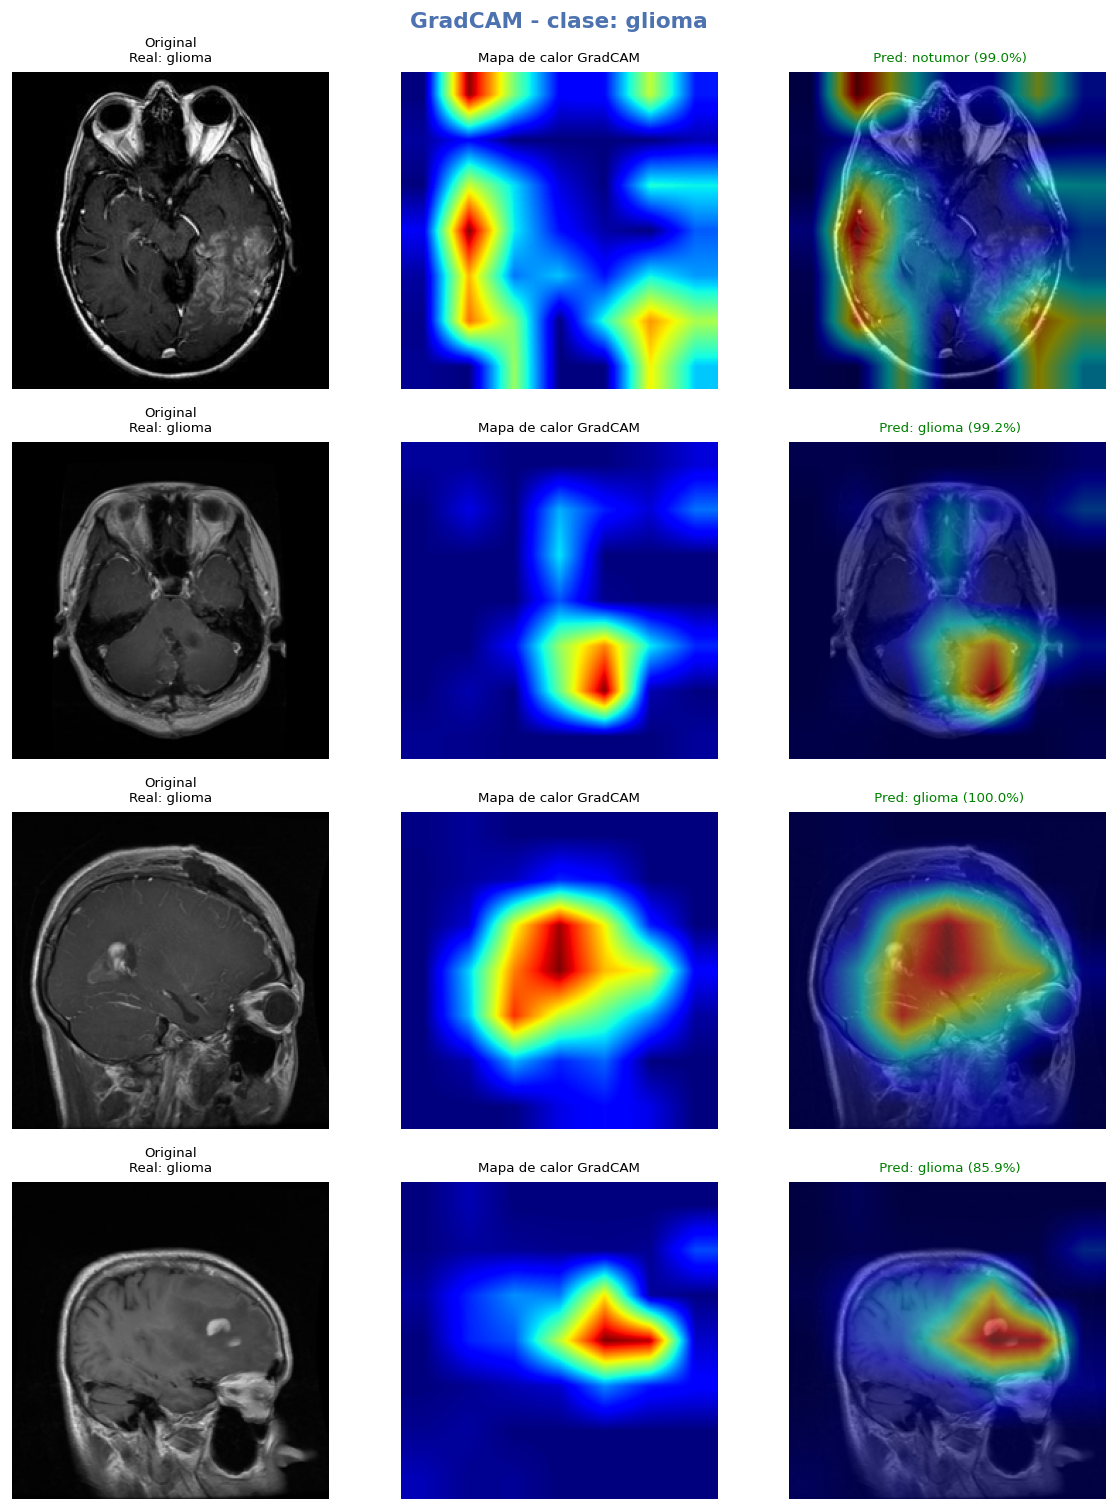

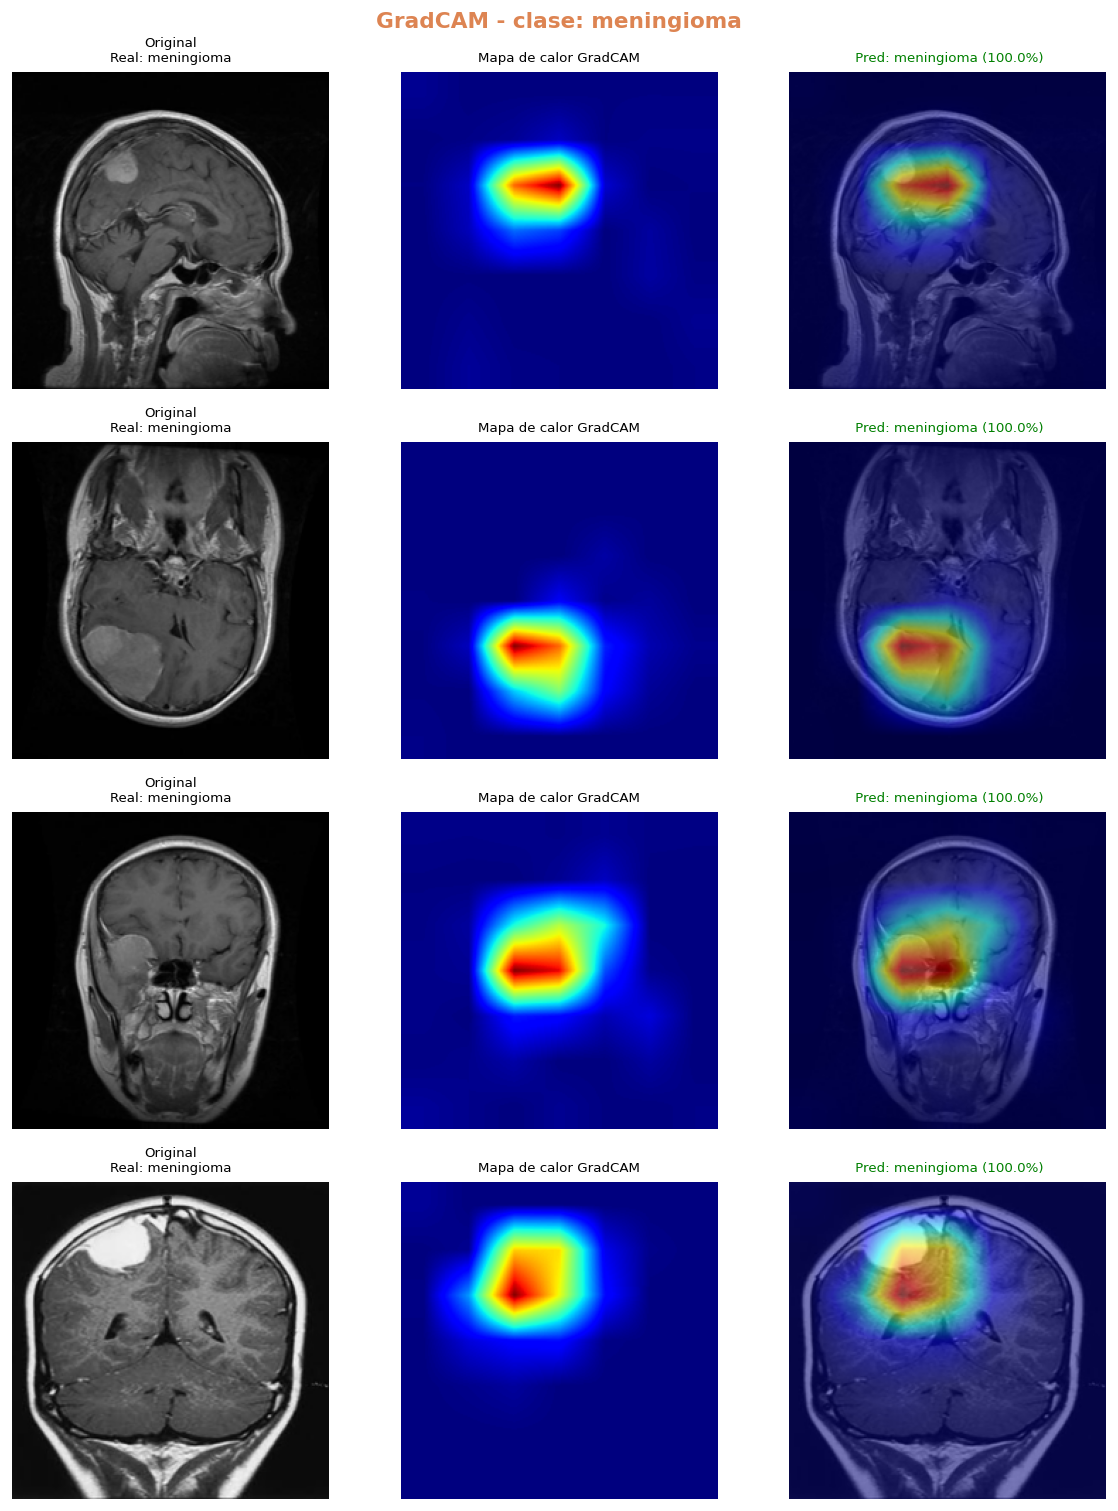

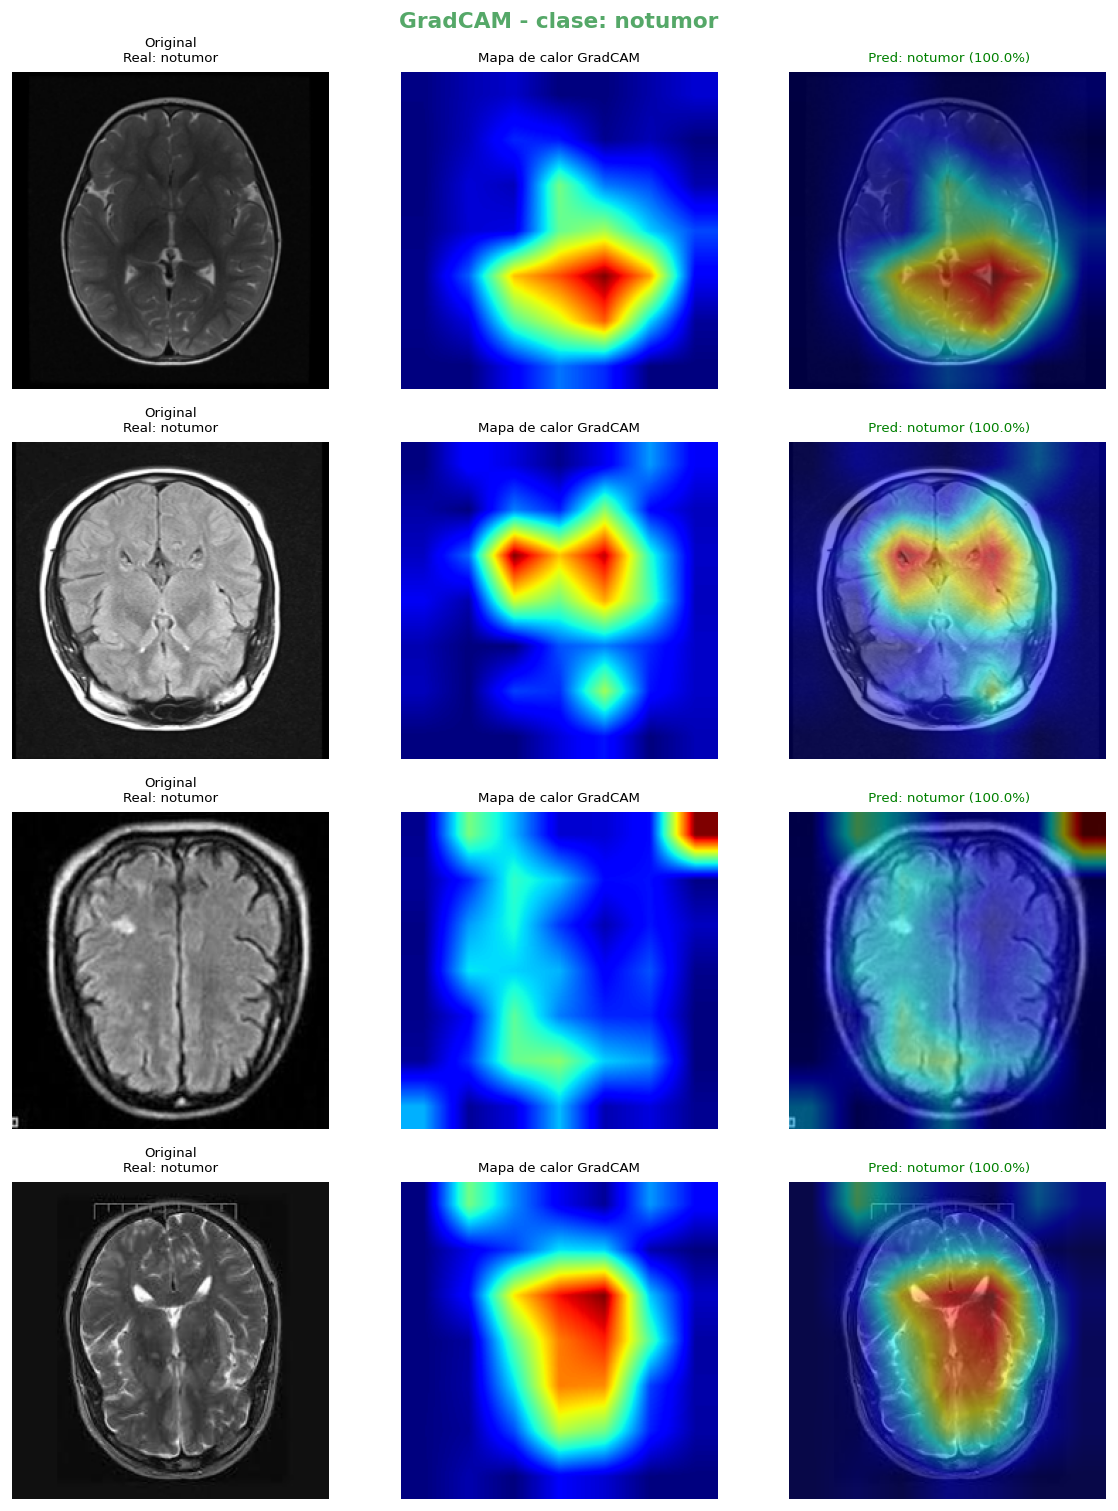

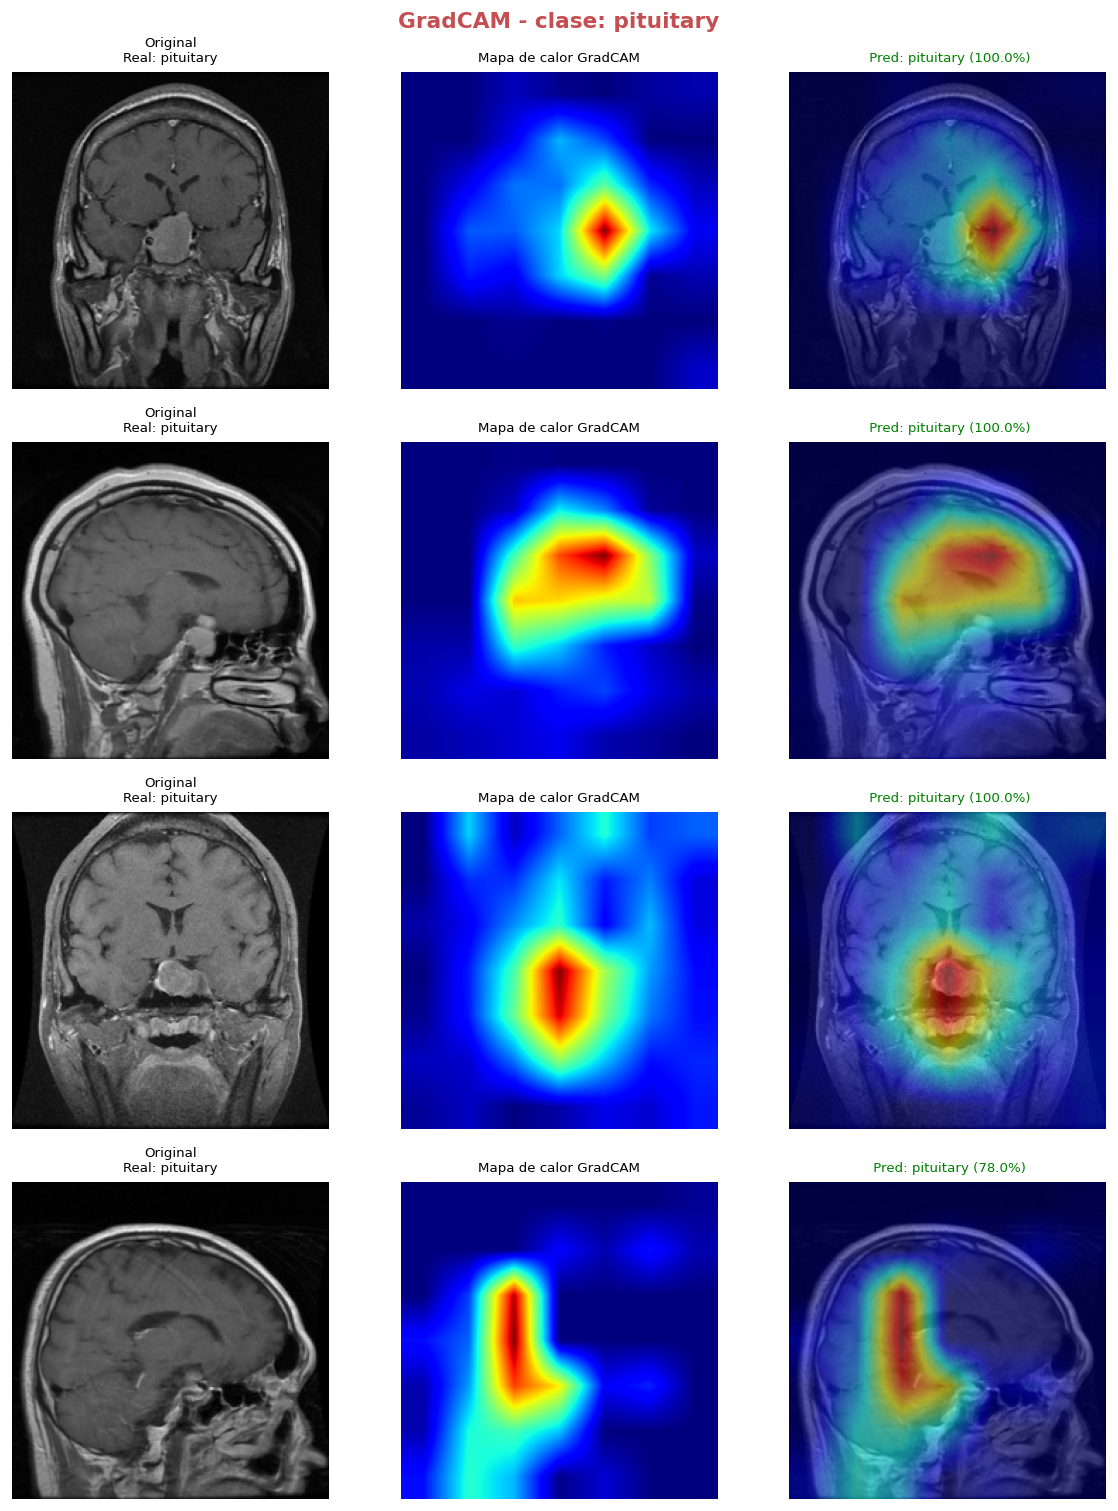

In [12]:
def gradcam_grid(clase, n_imgs=4):
    """
    Muestra una grid de n_imgs imágenes de la clase dada con:
    - Imagen original
    - Mapa de calor GradCAM
    - Superposición
    """
    folder = os.path.join(TEST_DIR, clase)
    files  = random.sample(os.listdir(folder), n_imgs)

    fig, axes = plt.subplots(n_imgs, 3, figsize=(10, n_imgs * 3.2))
    fig.suptitle(f'GradCAM - clase: {clase}', fontsize=13,
                 fontweight='bold', color=PALETTE[clase])

    for row, fname in enumerate(files):
        path          = os.path.join(folder, fname)
        tensor, img_pil = load_image(path)

        cam, pred_idx, probs = gradcam.generate(tensor)
        overlay, heatmap     = apply_heatmap(img_pil, cam)

        pred_clase    = IDX_CLASS[pred_idx]
        confianza     = probs[pred_idx] * 100
        correcto      = '' if pred_clase == clase else ''

        # Original
        axes[row][0].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        axes[row][0].set_title(f'Original\nReal: {clase}', fontsize=8)
        axes[row][0].axis('off')

        # Heatmap solo
        axes[row][1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[row][1].set_title('Mapa de calor GradCAM', fontsize=8)
        axes[row][1].axis('off')

        # Superposición
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(
            f'{correcto} Pred: {pred_clase} ({confianza:.1f}%)', fontsize=8,
            color='green' if correcto == '' else 'red'
        )
        axes[row][2].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{clase}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Visualizar las 4 clases
for clase in CLASES:
    gradcam_grid(clase, n_imgs=4)

Los mapas de calor por clase revelan que la activación GradCAM coincide con las regiones anatómicamente esperadas en la mayoría de casos.

- **glioma:** calor concentrado en la masa infiltrante dentro del parénquima cerebral, generalmente en los lóbulos frontal o temporal.
- **meningioma:** activación en el borde cortical donde la masa comprime el tejido desde el exterior, coherente con el origen extraaxial de este tumor.
- **pituitary:** foco muy localizado en la región selar central, reflejo de la pequeña y bien delimitada masa hipofisaria.
- **notumor:** activación dispersa por el tejido cerebral sin foco patológico claro, lo que indica que el modelo identifica correctamente la ausencia de anomalía localizada.

Este comportamiento sugiere que el modelo ha aprendido features clínicamente relevantes, y no artefactos del proceso de adquisición de las MRI (marcos, artefactos de movimiento, o sesgos del dataset).

## 4. Análisis de aciertos y errores
Comparar GradCAM en imágenes correctamente clasificadas vs mal clasificadas.
¿Mira el modelo al sitio correcto cuando falla?

In [ ]:
# Recopilar predicciones en todo el test set
from torchvision import datasets
from torch.utils.data import DataLoader

test_dataset = datasets.ImageFolder(TEST_DIR, transform=infer_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        _, preds = out.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_paths = [s[0] for s in test_dataset.samples]

acc_total = (all_preds == all_labels).mean()
print(f'Test Accuracy: {acc_total*100:.2f}%')
print(f'Errores: {(all_preds != all_labels).sum()} / {len(all_labels)}')

Test Accuracy: 95.12%
Errores: 78 / 1600


Con la tasa de error por clase calculada, podemos cuantificar qué clases son más problemáticas para el modelo. La distribución de errores confirma el patrón del EDA: la confusión es asimétrica y se concentra en el par **glioma-meningioma**, cuyas distribuciones de píxel son las más similares (μ=32.5 vs μ=44.8, según el Notebook 1). Las clases **notumor** y **pituitary** presentan una accuracy por clase notablemente superior, ya que sus características morfológicas y de localización son más distintivas y fácilmente separables por el modelo.

In [ ]:
# GradCAM comparativo: aciertos vs errores
# Para cada clase mostramos 2 aciertos y 2 errores
N_SHOW = 2

for clase in CLASES:
    cls_idx = CLASS_IDX[clase]

    # Índices de aciertos y errores para esta clase
    mask_clase   = all_labels == cls_idx
    aciertos_idx = np.where(mask_clase & (all_preds == all_labels))[0]
    errores_idx  = np.where(mask_clase & (all_preds != all_labels))[0]

    n_aciertos = min(N_SHOW, len(aciertos_idx))
    n_errores  = min(N_SHOW, len(errores_idx))

    if n_aciertos == 0 and n_errores == 0:
        continue

    sample_aciertos = np.random.choice(aciertos_idx, n_aciertos, replace=False)
    sample_errores  = np.random.choice(errores_idx,  n_errores,  replace=False) if n_errores > 0 else []

    total_cols = n_aciertos + n_errores
    fig, axes  = plt.subplots(3, total_cols, figsize=(total_cols * 3.2, 10))
    if total_cols == 1:
        axes = axes.reshape(3, 1)

    fig.suptitle(f'GradCAM aciertos vs errores - {clase}',
                 fontsize=12, fontweight='bold', color=PALETTE[clase])

    all_indices = list(sample_aciertos) + list(sample_errores)
    labels_col  = [' Acierto'] * n_aciertos + [' Error'] * n_errores

    for col, (idx, etiqueta) in enumerate(zip(all_indices, labels_col)):
        path           = test_paths[idx]
        tensor, img_pil = load_image(path)
        cam, pred_idx, probs = gradcam.generate(tensor)
        overlay, heatmap     = apply_heatmap(img_pil, cam)
        pred_clase = IDX_CLASS[pred_idx]
        confianza  = probs[pred_idx] * 100

        color_titulo = 'green' if '' in etiqueta else 'red'

        axes[0][col].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        axes[0][col].set_title(f'{etiqueta}\nReal: {clase}',
                               fontsize=8, color=color_titulo, fontweight='bold')
        axes[0][col].axis('off')

        axes[1][col].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[1][col].set_title('Mapa de calor', fontsize=8)
        axes[1][col].axis('off')

        axes[2][col].imshow(overlay)
        axes[2][col].set_title(f'Pred: {pred_clase} ({confianza:.1f}%)',
                               fontsize=8, color=color_titulo)
        axes[2][col].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_aciertos_errores_{clase}.png', dpi=150, bbox_inches='tight')
    plt.show()

El análisis comparativo aciertos vs errores expone el mecanismo de fallo del modelo. En los **aciertos**, el mapa de calor se concentra en la región del tumor con alta confianza; el modelo mira exactamente donde debe. En los **errores**, la activación se desplaza a regiones ambiguas o queda distribuida sin foco claro, lo que indica que la señal diagnóstica no es suficientemente nítida para el modelo en esa imagen concreta. Esto ocurre especialmente en:
- MRI con artefactos de adquisición o bajo contraste
- Tumores en estadio temprano con masa pequeña
- Ángulos de corte MRI inusuales que no representan bien la lesión

En ningún caso el modelo falla por activarse en regiones claramente incorrectas (p.ej., el cráneo óseo o el fondo negro), lo que confirma que el aprendizaje de features es coherente con el dominio médico.

## 5. Conclusiones

In [ ]:
# Estadísticas de errores por clase
import pandas as pd

rows = []
for clase in CLASES:
    cls_idx   = CLASS_IDX[clase]
    mask      = all_labels == cls_idx
    n_total   = mask.sum()
    n_correct = (all_preds[mask] == cls_idx).sum()
    rows.append({
        'Clase': clase,
        'Total': n_total,
        'Correctas': n_correct,
        'Errores': n_total - n_correct,
        'Accuracy (%)': round(n_correct / n_total * 100, 2)
    })

df_acc = pd.DataFrame(rows)
display(df_acc.style
    .highlight_max(subset=['Accuracy (%)'], color='#d4edda')
    .highlight_min(subset=['Accuracy (%)'], color='#ffd7d7')
    .set_caption('Accuracy por clase - test set'))

,Clase,Total,Correctas,Errores,Accuracy (%)
0,glioma,400,328,72,82.000000
1,meningioma,400,397,3,99.250000
2,notumor,400,400,0,100.000000
3,pituitary,400,397,3,99.250000


## Conclusiones - Object Detection con GradCAM

GradCAM convierte el clasificador entrenado en el Notebook 3 en una técnica de **localización de tumores sin necesidad de anotaciones de bounding boxes**. Es el estándar de facto en imágenes médicas porque obtener anotaciones manuales de radiólogos es costoso, lento y sujeto a variabilidad inter-observador.

Los resultados muestran que ResNet50 no solo clasifica correctamente las MRI, sino que **atiende a las regiones clínicamente relevantes**: la masa infiltrante en glioma, el borde cortical en meningioma, y la región selar en pituitary. En las imágenes sin tumor, la activación permanece dispersa sin foco patológico, lo que también es clínicamente coherente.

La confusión más frecuente (glioma-meningioma) se explica por su similitud morfológica en MRI de secuencia única - ya anticipada en el EDA por la proximidad de sus distribuciones de píxel. Para mejorar la discriminación sería necesario incorporar información de contraste (MRI con gadolinio) o secuencias adicionales (T1, T2, FLAIR) que no están disponibles en este dataset. En cualquier caso, el nivel de localización obtenido con GradCAM demuestra que el modelo ha aprendido representaciones con valor diagnóstico real, más allá de la simple clasificación de etiquetas.